In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad

from scipy.stats import gaussian_kde

from scipy.signal import savgol_filter

In [2]:
def binder_cumulant(ndata):

    distros = pd.read_csv(f'data/n={ndata}_c=0_m=0.csv', header=None).to_numpy()

    # vectorizado
    moment2 = np.mean(distros**2, axis=1)
    moment4 = np.mean(distros**4, axis=1)

    binder = 1 - moment4 / (3 * moment2**2)

    #binder_smooth = savgol_filter(binder, window_length=51, polyorder=3)

    return binder

In [3]:
timesteps = 1000

ndata_list = [100,500,1000,5000,10000,20000,21000,22000,23000,24000,25000,26000,27000,28000,29000,30000]

binder = np.zeros((len(ndata_list), timesteps))

for i in range(len(ndata_list)):

    binder[i] = binder_cumulant(ndata_list[i])



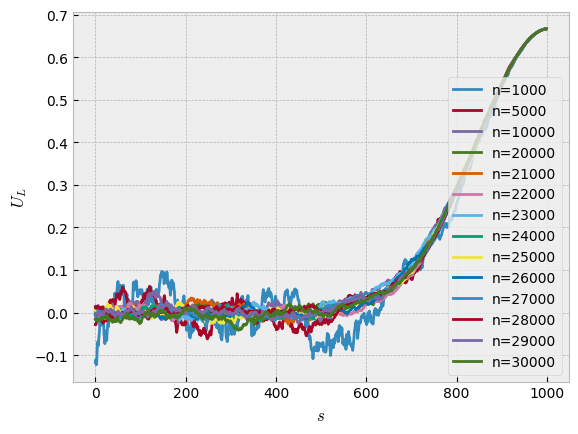

In [13]:
fig, ax = plt.subplots()

plt.style.use("bmh")

ax.set_xlabel(r'$s$')
ax.set_ylabel(r'$U_{L}$')

#ax.set_xlim(700,800)

for i in range(len(ndata_list)):

    if i // 2 != 0:

        ax.plot(binder[i], label=f'n={ndata_list[i]}')


ax.legend()
fig.savefig('figuras/binder_cumulant-two_deltas.pdf')


ValueError: x and y must have same first dimension, but have shapes (1000,) and (1,)

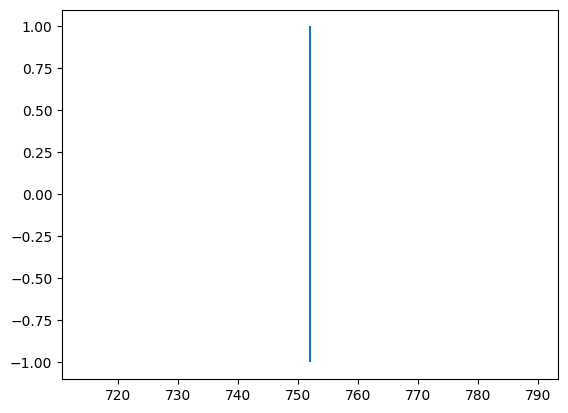

In [ ]:
fig, ax = plt.subplots()

#ax.set_xlim(700,800)

time_array = np.arange(timesteps)




#ax.vlines(752, ymin=-1,ymax=1)

#for i in range(len(ndata_list)):

    #ax.plot(time_array, binder[i], label=f'n={ndata_list[i]}')

#ax.legend()

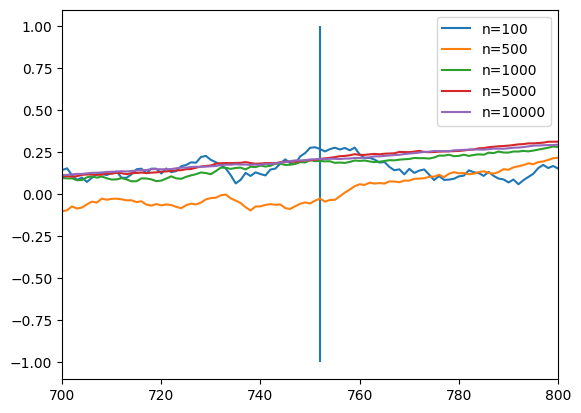

In [69]:
fig, ax = plt.subplots()

ax.set_xlim(700,800)

time_array = np.arange(timesteps)

ax.vlines(752, ymin=-1,ymax=1)

for i in range(len(ndata_list[:5])):

    ax.plot(time_array, binder[i], label=f'n={ndata_list[i]}')

ax.legend()